In [2]:
from PIL import Image
from torchvision import transforms

In [3]:
image = Image.open('../images/Cat_November_2010-1a.jpg')

tr = transforms.ToTensor()
tensor = tr(image)

print(tensor.shape)
print(tensor.min(), tensor.max())

torch.Size([3, 1282, 960])
tensor(0.) tensor(1.)


Преобразование изображения в тензор изменяет его форму: теперь сначала идут каналы, а затем высота и ширина, то есть формат становится `C x H x W` вместо `H x W x C`. 

Одновременно с этим преобразование масштабирует значения пикселей в диапазон от `0` до `1`, а не от `0` до `255`. 

## Pre-processing images for vision models

**Transformations** изменяют изображения так, чтобы привести их к единому и стандартизированному формату, подходящему для подачи в модель компьютерного зрения.

Обычно это обязательные шаги предобработки, которые переводят исходные файлы изображений в формат, понятный нейронной сети.

К важным преобразованиям относятся:

- **Resize** — изменение размера изображений до фиксированных размеров, например `64x64` или `32x32`;
- **Normalize** — нормализация значений пикселей в заданный диапазон;
- **Convert** — преобразование изображений из разных форматов в тензоры PyTorch.

In [ ]:
transform = transforms.Compose([transforms.Resize((64, 64)), 
                                transforms.ToTensor(), 
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

transformed_tensor = transform(image)

print("Tensor shape:", transformed_tensor.shape)  
print("Tensor min:", transformed_tensor.min())
print("Tensor max:", transformed_tensor.max())

Tensor shape: torch.Size([3, 64, 64])
Tensor min: tensor(-0.9294)
Tensor max: tensor(0.9529)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92941177..0.9529412].


Text(0.5, 1.0, 'With Normalization')

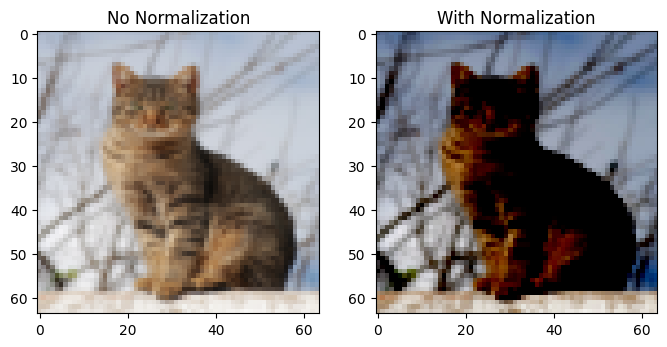

In [ ]:
import matplotlib.pyplot as plt

transform_no_norm = transforms.Compose([transforms.Resize((64, 64)), 
                                        transforms.ToTensor()])

transformed_tensor_no_norm = transform_no_norm(image)

def tensor_to_image(tensor):
    return tensor.permute(1, 2, 0).numpy()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(tensor_to_image(transformed_tensor_no_norm))
axs[0].set_title("No Normalization")
axs[1].imshow(tensor_to_image(transformed_tensor)) 
axs[1].set_title("With Normalization")


## Аугментации

**Аугментации** — это случайные, но реалистичные изменения обучающих изображений, которые искусственно увеличивают размер и разнообразие датасета.

Их основная цель:

- улучшить **обобщающую способность** модели;
- уменьшить **переобучение**.

### Основные техники аугментации

- **Flipping** — отражение изображения по горизонтали или вертикали;
- **Rotating** — поворот изображения на некоторый угол;
- **Color Jittering** — случайное изменение яркости, контраста, насыщенности и оттенка;
- **Cropping** — случайное вырезание части изображения;
- **Scaling and Translation** — изменение масштаба и сдвиг изображения;
- **Gaussian Blur or Noise** — добавление размытия или шума;
- **Affine Transformations** — комбинация поворота, сдвига, масштабирования и сдвига по осям.

### Зачем нужны аугментации

Аугментации помогают модели видеть один и тот же объект в разных условиях:

- под разными углами;
- при разном освещении;
- в разных положениях и масштабах;
- с небольшими искажениями.

Благодаря этому модель лучше распознаёт важные признаки объекта и меньше запоминает только обучающие примеры.

### Применение в PyTorch

Для применения нескольких аугментаций подряд удобно использовать `transforms.Compose`:

```python
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])
```

Этот пример делает следующее:

- случайно отражает изображение по горизонтали;
- случайно поворачивает его в пределах `±15` градусов;
- случайно изменяет яркость и контраст.

### Training и Testing

Аугментации применяются только к **обучающему набору**.

К **тестовому набору** их не применяют, потому что тестовые данные нужны для честной проверки качества модели на новых, не изменённых изображениях.

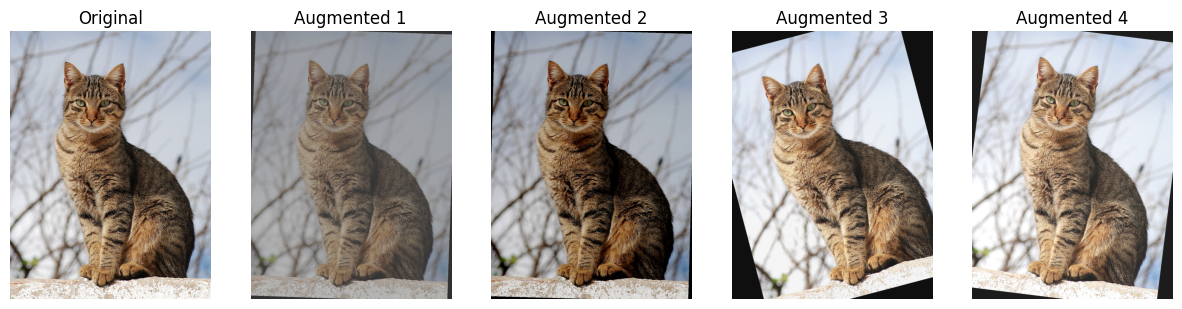

In [ ]:
augment = transforms.Compose([transforms.RandomHorizontalFlip(0.6), transforms.RandomRotation(15),
                              transforms.ColorJitter(brightness=0.4, contrast=0.4)])

augmented_image = augment(image)

fig, axs = plt.subplots(1, 5, figsize=(15, 4))
axs[0].imshow(image)
axs[0].set_title("Original")
axs[0].axis('off')

for i in range(1, 5):
    augmented = augment(image)
    axs[i].imshow(augmented)
    axs[i].set_title(f"Augmented {i}")
    axs[i].axis('off')

In [1]:
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.Resize((32, 32)), transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(10), transforms.ColorJitter(brightness=0.2, contrast=0.2),
                                transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

dataset = datasets.CIFAR10(root='../data/', 
                           train=True, 
                           transform=transform, 
                           download=True)

from torch.utils.data import Subset
subset_indices = list(range(20000))
subset_train_dataset = Subset(dataset, subset_indices)
print(len(subset_train_dataset)) 

100%|██████████| 170498071/170498071 [00:08<00:00, 20708664.68it/s]


Extracting ../data/cifar-10-python.tar.gz to ../data/
20000


In [2]:
print(dataset.classes)
print(dataset.targets)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
[6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6, 4, 3, 6, 6, 2, 6, 3, 5, 4, 0, 0, 9, 1, 3, 4, 0, 3, 7, 3, 3, 5, 2, 2, 7, 1, 1, 1, 2, 2, 0, 9, 5, 7, 9, 2, 2, 5, 2, 4, 3, 1, 1, 8, 2, 1, 1, 4, 9, 7, 8, 5, 9, 6, 7, 3, 1, 9, 0, 3, 1, 3, 5, 4, 5, 7, 7, 4, 7, 9, 4, 2, 3, 8, 0, 1, 6, 1, 1, 4, 1, 8, 3, 9, 6, 6, 1, 8, 5, 2, 9, 9, 8, 1, 7, 7, 0, 0, 6, 9, 1, 2, 2, 9, 2, 6, 6, 1, 9, 5, 0, 4, 7, 6, 7, 1, 8, 1, 1, 2, 8, 1, 3, 3, 6, 2, 4, 9, 9, 5, 4, 3, 6, 7, 4, 6, 8, 5, 5, 4, 3, 1, 8, 4, 7, 6, 0, 9, 5, 1, 3, 8, 2, 7, 5, 3, 4, 1, 5, 7, 0, 4, 7, 5, 5, 1, 0, 9, 6, 9, 0, 8, 7, 8, 8, 2, 5, 2, 3, 5, 0, 6, 1, 9, 3, 6, 9, 1, 3, 9, 6, 6, 7, 1, 0, 9, 5, 8, 5, 2, 9, 0, 8, 8, 0, 6, 9, 1, 1, 6, 3, 7, 6, 6, 0, 6, 6, 1, 7, 1, 5, 8, 3, 6, 6, 8, 6, 8, 4, 6, 6, 1, 3, 8, 3, 4, 1, 7, 1, 3, 8, 5, 1, 1, 4, 0, 9, 3, 7, 4, 9, 9, 2, 4, 9, 9, 1, 0, 5, 9, 0, 8, 2, 1, 2, 0, 5, 6, 3, 2, 7, 8, 8, 6, 0, 7, 9, 4, 5, 6, 4, 2, 1, 1,

In [3]:
import torch
from torch.utils.data import random_split, DataLoader

torch.manual_seed(42) 

train_size = 0.80
val_size = 0.20
train_dataset, val_dataset = random_split(subset_train_dataset, [train_size, val_size])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Training set size:", len(train_dataset))
print("Validation set size:", len(val_dataset))

Training set size: 16000
Validation set size: 4000


In [4]:
test_transform = transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor(),
                                     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

test_dataset = datasets.CIFAR10(root='../data/', train=False, transform=test_transform, download=True)

test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Files already downloaded and verified


Полносвязные нейронные сети (**FNN**) плохо работают с изображениями по двум основным причинам:

- им требуется слишком большое количество параметров для обработки всех пикселей;
- они не учитывают пространственные связи между соседними пикселями.

Из-за этого обработка изображений становится вычислительно дорогой, а качество работы на задачах компьютерного зрения оказывается хуже.

## CNN

**CNN** (*Convolutional Neural Network*, сверточная нейронная сеть) — это тип нейронной сети, специально предназначенный для работы с изображениями.

CNN содержит специальные слои, которые умеют находить локальные связи между соседними участками изображения.

## Сверточные слои

Сверточные слои используют **фильтры** (*kernels*) — небольшие матрицы, например `3x3`, веса которых обучаются в процессе обучения сети.

Фильтр перемещается по изображению и в каждой позиции вычисляет взвешенную сумму $a_{11} k_{11} + a_{12} k_{12} + a_{13} k_{13} + a_{21} k_{21} + a_{22} k_{22} + a_{23} k_{23} + a_{31} k_{31} + a_{32} k_{32} + a_{33} k_{33}$ значений пикселей.

Результат работы фильтра формирует **карту признаков** (*feature map*).

Каждый фильтр создаёт одну карту признаков и обнаруживает определённый шаблон на изображении.

Если изображение имеет несколько каналов, свёртка выполняется по всем каналам, а число выходных карт признаков определяется количеством фильтров.

### Что показывает feature map

Карта признаков показывает, насколько сильно определённый шаблон выражен в разных частях изображения.

Чем выше значение активации в карте признаков, тем сильнее соответствующий признак обнаружен в данной области изображения.

## Почему CNN хорошо работают с изображениями

### Parameter efficiency

Фильтры скользят по изображению и используют одни и те же веса в разных его частях.

Это резко уменьшает число параметров по сравнению с FNN.

### Local pattern detection

Каждый фильтр смотрит только на небольшой участок изображения, например `3x3` или `5x5`.

Это позволяет находить локальные признаки:

- края;
- углы;
- текстуры.

### Translation invariance

Поскольку фильтр применяется ко всему изображению, сеть может распознавать один и тот же объект в разных местах изображения.

Это улучшает способность модели к обобщению.

### Hierarchical learning

Ранние сверточные слои учатся находить простые признаки, например линии и края.

Более глубокие слои комбинируют их в более сложные объекты, например лица, животных или машины.

### Главное

CNN лучше подходят для изображений, потому что они:

- сохраняют пространственные связи;
- требуют меньше параметров;
- находят важные визуальные шаблоны;
- лучше работают в задачах классификации и компьютерного зрения.

## Компоненты CNN

В PyTorch сверточные нейронные сети обычно строятся с помощью модуля `torch.nn.Conv2d`.

Каждый слой `Conv2d` определяется несколькими важными параметрами:

- размер фильтра;
- количество фильтров;
- шаг (`stride`);
- отступ (`padding`).

### Размер фильтра

Параметр `kernel_size` задаёт высоту и ширину фильтра.

Часто используют фильтры размера `3x3` или `5x5`.

Меньшие ядра лучше сохраняют пространственное разрешение, а большие ядра захватывают более крупные шаблоны, но уменьшают пространственный размер изображения.

Обычно выбирают нечётные размеры, чтобы у фильтра был чётко определённый центр.

### Количество фильтров

Каждый сверточный слой применяет к изображению несколько фильтров.

Каждый фильтр учится находить определённый признак, например:

- края;
- углы;
- текстуры.

Если к изображению применяется несколько фильтров, то на выходе получается несколько каналов — по одному на каждый фильтр.

```python
import torch.nn as nn
conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3)
```

- `in_channels` — число входных каналов, например `3` для RGB-изображения;
- `out_channels` — число фильтров, то есть сколько карт признаков будет получено на выходе.

Форма выходного тензора будет такой:

`(batch_size, out_channels, new_height, new_width)`

### Stride

Параметр `stride` задаёт, на сколько пикселей фильтр сдвигается за один шаг.

По умолчанию `stride=1`, то есть фильтр перемещается по изображению по одному пикселю.

```python
conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=2)
```

Если `stride` больше, размер выходного изображения уменьшается.

Например, при `stride=2` высота и ширина выходного тензора примерно уменьшаются в 2 раза.

### Padding

Параметр `padding` определяет, что происходит на границах изображения.

Основные варианты:

- **valid padding** — без добавления рамки, поэтому выход уменьшается;
- **same padding** — вокруг изображения добавляются нули, чтобы при `stride=1` размер выхода сохранялся.

### Пример слоя CNN

```python
import torch.nn as nn

class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels=3,      # RGB image
            out_channels=16,    # 16 filters
            kernel_size=5,      # 5x5 filters
            stride=2,           # move 2 pixels at a time
            padding=2           # same padding
        )
    
    def forward(self, x):
        return self.conv1(x)
```

### Главное

При создании слоя CNN веса фильтров сначала инициализируются случайными значениями.

Затем во время обучения они постепенно настраиваются с помощью backpropagation, чтобы находить полезные признаки на изображениях.

In [ ]:
import torch
from torch import nn

# Dummy input: batch of 1 RGB image (3 channels), size 32x32
x = torch.randn(1, 3, 32, 32)

conv3 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3)
conv5 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=5)

out3 =  conv3(x)
out5 =  conv5(x)

print("Input shape:",  x.shape)
print("Output shape with 3x3 kernel:",  out3.shape)
print("Output shape with 5x5 kernel:",  out5.shape)

conv_stride1 =  nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, stride=1)
conv_stride2 =  nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, stride=2)

out_stride1 = conv_stride1(x)
out_stride2 = conv_stride2(x)

print("Output shape with stride=1:",  out_stride1.shape)
print("Output shape with stride=2:", out_stride2.shape)

conv_no_pad =  nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=0)
conv_pad =  nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1)

out_no_pad = conv_no_pad(x)
out_pad = conv_pad(x)

print("Output shape without padding:", out_no_pad.shape)
print("Output shape with padding=1:", out_pad.shape)

Input shape: torch.Size([1, 3, 32, 32])
Output shape with 3x3 kernel: torch.Size([1, 1, 30, 30])
Output shape with 5x5 kernel: torch.Size([1, 1, 28, 28])
Output shape with stride=1: torch.Size([1, 1, 30, 30])
Output shape with stride=2: torch.Size([1, 1, 15, 15])
Output shape without padding: torch.Size([1, 1, 30, 30])
Output shape with padding=1: torch.Size([1, 1, 32, 32])


## Pooling layers

**Pooling layers** обычно применяются после сверточных слоёв для уменьшения размерности модели.

Pooling использует скользящее окно, например `2x2`, которое проходит по карте признаков и заменяет каждую область одним представительным значением.

Этот процесс уменьшения размерности называется **downsampling**.

### Виды pooling

- **Max pooling** — выбирает максимальное значение в каждом окне;
- **Min pooling** — выбирает минимальное значение;
- **Average pooling** — вычисляет среднее значение.

Обычно шаг (`stride`) выбирают равным размеру окна pooling, чтобы области не перекрывались.

### Пример max pooling

Если применить `2x2` max pooling к карте признаков размера `(12, 32, 32)`, то результат будет иметь размер `(12, 16, 16)`.

То есть высота и ширина уменьшаются в 2 раза.

Уменьшение размерности ускоряет обучение, потому что снижает объём данных, которые дальше обрабатывает сеть.

### Pooling в PyTorch

```python
nn.MaxPool2d(kernel_size=2, stride=2)
```

### Формула выходного размера

Для вычисления размера выхода сверточного или pooling-слоя используется формула:

$
O = \frac{I - K + 2P}{S} + 1
$

где:

- `I` — размер входа;
- `K` — размер ядра;
- `P` — padding;
- `S` — stride;
- `O` — размер выхода.

Input shape: torch.Size([1, 3, 32, 32])
Max pooled shape: torch.Size([1, 3, 16, 16])
Avg pooled shape: torch.Size([1, 3, 16, 16])


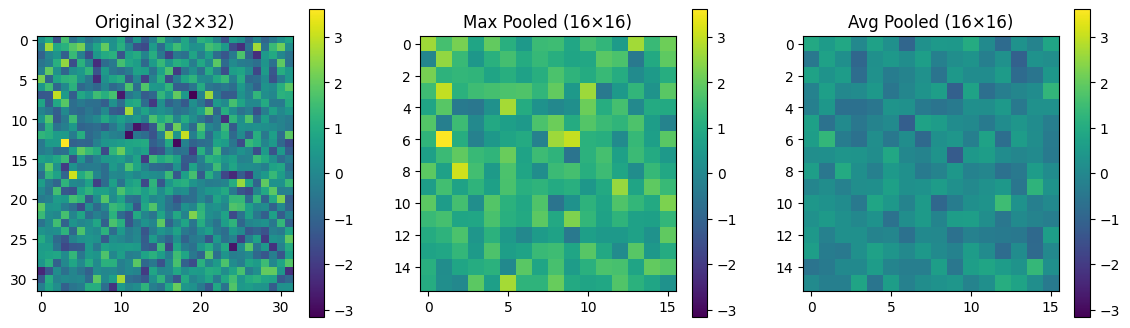

In [ ]:
maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
avgpool = nn.AvgPool2d(kernel_size=2, stride=2)

max_pooled = maxpool(x)
avg_pooled = avgpool(x)

print("Input shape:", x.shape)
print("Max pooled shape:", max_pooled.shape)
print("Avg pooled shape:", avg_pooled.shape)

# Convert tensors to numpy arrays for visualization
original = x[0, 0].detach().numpy()
max_img = max_pooled[0, 0].detach().numpy()
avg_img = avg_pooled[0, 0].detach().numpy()

# Determine global vmin and vmax for consistent color scaling
vmin = min(original.min(), max_img.min(), avg_img.min())
vmax = max(original.max(), max_img.max(), avg_img.max())

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

# Visualize original
im0 = axs[0].imshow(original, cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].set_title("Original (32×32)")
plt.colorbar(im0, ax=axs[0])

# Visualize max_img
im1 = axs[1].imshow(max_img, cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title("Max Pooled (16×16)")
plt.colorbar(im1, ax=axs[1])

# Visualize avg_img
im2 = axs[2].imshow(avg_img, cmap='viridis', vmin=vmin, vmax=vmax)
axs[2].set_title("Avg Pooled (16×16)")
plt.colorbar(im2, ax=axs[2])

In [5]:
import torch.nn.functional as F
from torch import nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(4096, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = SimpleCNN().to(device)  
print(device)

cuda


In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005)

In [9]:
train_losses = []
val_losses = []

num_epochs = 5
for epoch in range(num_epochs):
    total_train_loss = 0
    total_val_loss = 0 

    cnn_model.train()
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out = cnn_model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    
    cnn_model.eval()
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            out = cnn_model(images)
            val_loss = criterion(out, labels)
            total_val_loss += val_loss.item()

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_val_loss = total_val_loss / len(val_dataloader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]: Training Loss: {avg_train_loss:.4f} - Validation Loss: {avg_val_loss:.4f}")

Epoch [1/5]: Training Loss: 1.7588 - Validation Loss: 1.5291
Epoch [2/5]: Training Loss: 1.4457 - Validation Loss: 1.3724
Epoch [3/5]: Training Loss: 1.3166 - Validation Loss: 1.2849
Epoch [4/5]: Training Loss: 1.2193 - Validation Loss: 1.1757
Epoch [5/5]: Training Loss: 1.1385 - Validation Loss: 1.1619


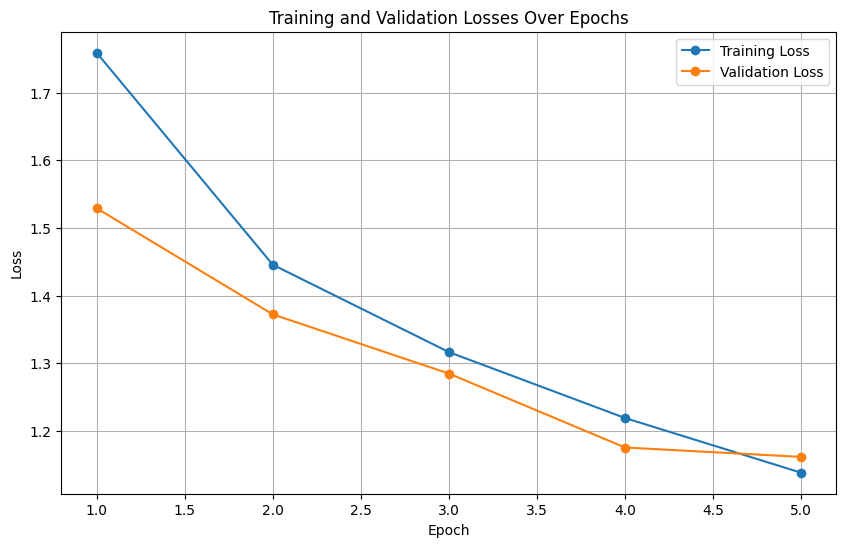

In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
test_pred_probs = []
test_pred_labels = []

with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        out = cnn_model(images)
        probs = F.softmax(out, dim=1)
        label = torch.argmax(out, dim=1)

        test_pred_probs.extend(probs.cpu().numpy())
        test_pred_labels.extend(label.cpu().numpy())
        
print("First image predicted probabilities:", test_pred_probs[0])
print("First image predicted label:", test_pred_labels[0])

First image predicted probabilities: [0.02784594 0.00083293 0.04909449 0.42893013 0.00542906 0.3399049
 0.08953466 0.00140628 0.05546793 0.00155366]
First image predicted label: 3


In [12]:
from sklearn.metrics import classification_report

test_labels = test_dataset.targets
cifar10_classes = test_dataset.classes
report = classification_report(test_labels, test_pred_labels, target_names=cifar10_classes)

print(report)

              precision    recall  f1-score   support

    airplane       0.62      0.68      0.65      1000
  automobile       0.61      0.86      0.71      1000
        bird       0.46      0.51      0.48      1000
         cat       0.59      0.22      0.32      1000
        deer       0.55      0.52      0.54      1000
         dog       0.50      0.57      0.53      1000
        frog       0.72      0.70      0.71      1000
       horse       0.57      0.76      0.65      1000
        ship       0.71      0.73      0.72      1000
       truck       0.80      0.47      0.59      1000

    accuracy                           0.60     10000
   macro avg       0.61      0.60      0.59     10000
weighted avg       0.61      0.60      0.59     10000



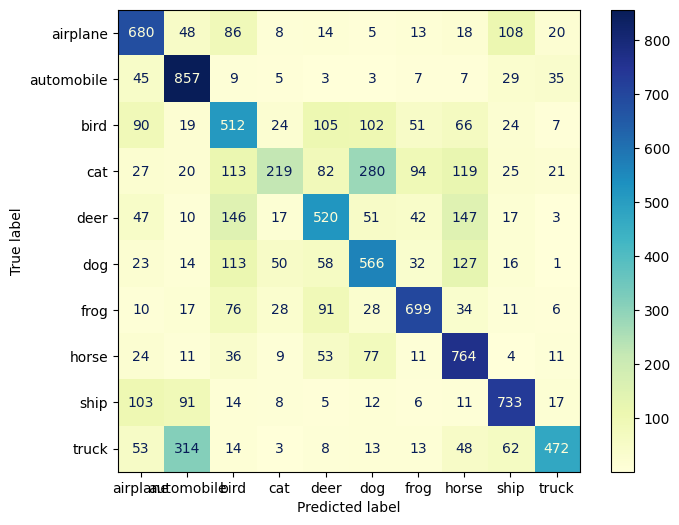

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(test_labels, test_pred_labels)

fig, ax = plt.subplots(figsize=(8,6), dpi=100)

display = ConfusionMatrixDisplay(conf_matrix, display_labels=cifar10_classes)

display.plot(ax=ax, cmap='YlGnBu')